![banner image](images/bannerImage.png)

## Project Overview

This project applies hypothesis testing techniques to evaluate the safety profile of a pharmaceutical drug using clinical trial data. The dataset contains observations from a randomized controlled trial conducted by GlobalXYZ, where participants were assigned to either a Drug group or a Placebo group.

The main objective of this analysis is to determine whether the drug is associated with adverse effects when compared with the placebo. The analysis focuses on the presence of adverse effects, the number of adverse effects experienced by participants, and whether the age distribution differs between treatment groups.

Using statistical methods such as a two-sample proportions z-test, chi-square test of independence, and appropriate group comparison tests for age, this project investigates whether observed differences between the Drug and Placebo groups are statistically significant.

## Objectives

The key objectives of this project are to:

1. Determine whether the proportion of participants experiencing adverse effects differs significantly between the Drug and Placebo groups.
2. Test whether the number of adverse effects is independent of the treatment group.
3. Examine the age distribution of participants in each treatment group.
4. Determine whether there is a statistically significant difference in age between the Drug and Placebo groups.

## Dataset Description

The dataset used in this project is `drug_safety.csv`. It includes demographic information, treatment assignment, laboratory measures, and adverse effect outcomes.

The original dataset was obtained from [Hbiostat](https://hbiostat.org/data/repo/safety.rda) courtesy of the Vanderbilt University Department of Biostatistics. 

For this project, the dataset has been modified to reflect the presence and absence of adverse effects `adverse_effects` and the number of adverse effects in a single individual `num_effects`.

Key columns include:

- `sex`: Gender of the participant
- `age`: Age of the participant
- `week`: Week of drug testing
- `trx`: Treatment group, either Drug or Placebo
- `wbc`: White blood cell count
- `rbc`: Red blood cell count
- `adverse_effects`: Whether the participant experienced at least one adverse effect
- `num_effects`: Number of adverse effects experienced by the participant

## Statistical Approach

The project is completed through the following steps:

- Conduct a two-sample proportions z-test to compare adverse effect rates between groups.
- Perform a chi-square test of independence to assess the relationship between treatment group and number of adverse effects.
- Inspect whether age is normally distributed within each group.
- Apply an appropriate statistical test to compare participant ages between the Drug and Placebo groups.

In [2]:
# Import packages
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
import pingouin
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
drug_safety = pd.read_csv("dataset/drug_safety.csv")

drug_safety.head()

,age,sex,trx,week,wbc,rbc,adverse_effects,num_effects
0,62,male,Drug,0,7.3,5.1,No,0
1,62,male,Drug,1,NaN,NaN,No,0
2,62,male,Drug,12,5.6,5.0,No,0
3,62,male,Drug,16,NaN,NaN,No,0
4,62,male,Drug,2,6.6,5.1,No,0


In [3]:
drug_safety.shape

(16103, 8)

## **Task 1: Two-sample proportions z-test**

### Getting the count of successes and total counts

- In this scenario, a "success" would be where "adverse_effects" is "True", and we want to compare the difference between the two "trx" groups - "Drug" and "Placebo".

- We can create a variable containing the frequency of "adverse_effects" for each group, which can be done using the chained pandas DataFrame .groupby("group").column.value_counts() function.

In [7]:
# Count successes and total observations for each treatment group
adv_eff_by_trx = drug_safety.groupby("trx")["adverse_effects"].value_counts()

adv_eff_by_trx

trx      adverse_effects
Drug     No                 9703
         Yes                1024
Placebo  No                 4864
         Yes                 512
Name: count, dtype: int64

- You can get the total counts in each group by calculating the sum of successes and failures within each group. You may use dataframe.groupby("group").column.count() to get them.

In [8]:
# Total number of observations in each group
n_obs = drug_safety.groupby("trx")["adverse_effects"].count()

n_obs

trx
Drug       10727
Placebo     5376
Name: adverse_effects, dtype: int64

### Performing a two-sample proportions z-test
- Put the number of successes in each group in a list or numpy array.
- Also, put each group's total number of observations (rows) in a list or numpy array.
- The proportions_ztest() function takes the number of successes and total number of observations, returning a tuple containing the z-statistic and p-value.
- Save the results of the test as the variable two_sample_results and subset the second element using two_sample_results[1]

In [9]:
successes = np.array([1024, 512])
tot_observations = np.array([10727, 5376])

In [10]:
two_sample_results = proportions_ztest(
    count=successes,
    nobs=tot_observations
)

In [11]:
print(two_sample_results)

(np.float64(0.0452182684494942), np.float64(0.9639333330262475))


In [12]:
two_sample_p_value = two_sample_results[1]

In [13]:
# Interpret the result
alpha = 0.05

if two_sample_p_value < alpha:
    print("Reject the null hypothesis.")
    print("The proportion of adverse effects differs significantly between the Drug and Placebo groups.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in adverse effect proportions between the Drug and Placebo groups.")

Fail to reject the null hypothesis.
There is no statistically significant difference in adverse effect proportions between the Drug and Placebo groups.


## **Task 2: Association between adverse effects and the groups**
Test if num_effects and trx are independent to determine whether trx influences the number of effects.

### Performing a Chi-square test of independence
- Use the pingouin.chi2_independence() function to perform a Chi-square test of independence.
- This function requires three arguments - data, x, and y.
- The third element of the tuple returned by pingouin.chi2_independence() contains the test statistics.
- Subset for the p-value of the test by extracting the third element, its p-value, then the first element, e.g. num_effects_p_value = num_effects_groups[2]["pval"][0]

In [14]:
# Perform Chi-square test of independence
num_effects_groups = pingouin.chi2_independence(
    data=drug_safety,
    x="num_effects",
    y="trx"
)

num_effects_groups

c:\Users\midem\Documents\statistical-analysis-of-drug-safety-using-hypothesis-testing\venv\Lib\site-packages\pingouin\contingency.py:152: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
c:\Users\midem\Documents\statistical-analysis-of-drug-safety-using-hypothesis-testing\venv\Lib\site-packages\pingouin\contingency.py:152: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")


(trx                 Drug      Placebo
 num_effects                          
 0            9703.794883  4863.205117
 1             960.587096   481.412904
 2              58.621126    29.378874
 3               3.996895     2.003105,
 trx          Drug  Placebo
 num_effects               
 0            9703     4864
 1             956      486
 2              63       25
 3               5        1,
                  test    lambda      chi2  dof      pval    cramer     power
 0             pearson  1.000000  1.799644  3.0  0.615012  0.010572  0.176275
 1        cressie-read  0.666667  1.836006  3.0  0.607131  0.010678  0.179153
 2      log-likelihood  0.000000  1.922495  3.0  0.588648  0.010926  0.186033
 3       freeman-tukey -0.500000  2.001752  3.0  0.572043  0.011149  0.192379
 4  mod-log-likelihood -1.000000  2.096158  3.0  0.552690  0.011409  0.199984
 5              neyman -2.000000  2.344303  3.0  0.504087  0.012066  0.220189)

In [15]:
# Extract the p-value from the third element of the returned tuple
num_effects_p_value = num_effects_groups[2]["pval"][0]

num_effects_p_value

np.float64(0.6150123339426765)

### Interpretation of Chi-Square Test

The Chi-square test of independence was conducted to evaluate whether there is an association between the treatment group (`trx`) and the number of adverse effects (`num_effects`).

- **P-value:** 0.6150  
- **Significance level (α):** 0.05  

Since the p-value is greater than the significance level, we **fail to reject the null hypothesis**.

There is **no statistically significant association** between the treatment group and the number of adverse effects experienced by participants. This suggests that the number of adverse effects is **independent of whether a participant received the Drug or Placebo**.

### Additional Insight

The effect size (Cramér’s V ≈ 0.01) indicates a **very weak relationship**, further supporting the conclusion that the treatment does not meaningfully influence the number of adverse effects.

## **Task 3: Inspecting whether age is normally distributed**
To determine what test to use to confirm whether age differs significantly between the trx groups you need to check if age is normally distributed in the trx groups. This can be done visually or by using a statistical test.

### Creating a histogram
- Use the sns.histplot() function to create a histogram.
- Set the hue parameter to a group of interest.

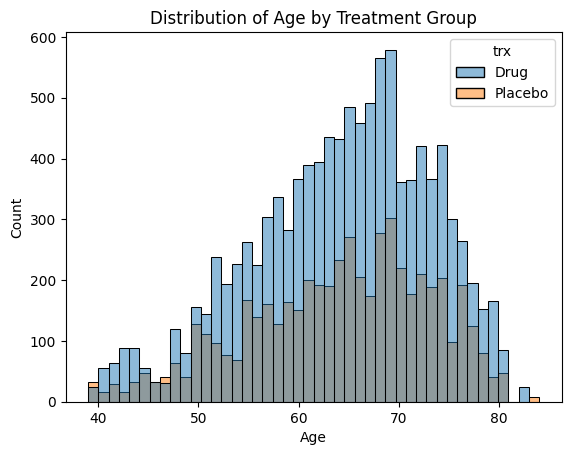

In [16]:
# Create a histogram of age by treatment group
sns.histplot(
    data=drug_safety,
    x="age",
    hue="trx"
)

plt.title("Distribution of Age by Treatment Group")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Testing for normality
- To formally test for a difference in distributions of age between the two trx groups you can perform a Shapiro-Wilks test using pengouin.normality().
- This function takes three arguments - data, dv (dependent variable), and group.

In [17]:
# Test for normality of age within each treatment group
age_normality = pingouin.normality(
    data=drug_safety,
    dv="age",
    group="trx"
)

age_normality

c:\Users\midem\Documents\statistical-analysis-of-drug-safety-using-hypothesis-testing\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10727.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\midem\Documents\statistical-analysis-of-drug-safety-using-hypothesis-testing\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5376.
  res = hypotest_fun_out(*samples, **kwds)


,W,pval,normal
trx,,,
Drug,0.976763,2.117243e-38,False
Placebo,0.975600,2.236347e-29,False


In [18]:
# Interpret normality test result
alpha = 0.05

if (age_normality["pval"] < alpha).any():
    print("At least one treatment group has age values that are not normally distributed.")
else:
    print("Age appears to be normally distributed in both treatment groups.")

At least one treatment group has age values that are not normally distributed.


## **Task 4: Significant difference between the ages of both groups**
To ensure age wasn't a confounder, conduct a Mann-Whitney test to determine if age differed significantly between the trx groups.

### Performing a Mann-Whitney U test
- You can create two variables, age_trx and age_placebo by filtering where trx is "Drug" and subsetting the age column, then repeating where trx is "Placebo".
- The above can be done using df.loc[] syntax.
- You can use the pingouin.mwu() function to perform a Mann-Whitney U test.
- This function returns a pandas DataFrame, from which you can then extract the "p-val" column using square brackets [], saving as a variable called age_group_effects_p_value.

In [22]:
# Create age variables for each treatment group
age_trx = drug_safety.loc[drug_safety["trx"] == "Drug", "age"]
age_placebo = drug_safety.loc[drug_safety["trx"] == "Placebo", "age"]

# Perform Mann-Whitney U test
age_group_effects = pingouin.mwu(
    x=age_trx,
    y=age_placebo
)

age_group_effects

,U_val,alternative,p_val,RBC,CLES
MWU,29149339.5,two-sided,0.256963,0.01093,0.505465


In [27]:
# Extract the p-value
age_group_effects_p_value = age_group_effects["p_val"].iloc[0]

age_group_effects_p_value

np.float64(0.25696267004066287)

In [28]:
# Interpret the result
alpha = 0.05

if age_group_effects_p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in age between the Drug and Placebo groups.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in age between the Drug and Placebo groups.")

Fail to reject the null hypothesis.
There is no statistically significant difference in age between the Drug and Placebo groups.


## **Conclusion**

This project used hypothesis testing to evaluate whether the clinical trial data provided evidence of drug safety concerns when comparing the Drug and Placebo groups.

The two-sample proportions z-test produced a p-value of **0.9639**, which is greater than the 0.05 significance level. Therefore, we failed to reject the null hypothesis and concluded that there is **no statistically significant difference in the proportion of adverse effects** between the Drug and Placebo groups.

The Chi-square test of independence produced a p-value of **0.6150**. Since this is also greater than 0.05, we failed to reject the null hypothesis. This suggests that the **number of adverse effects is independent of treatment group**.

The Shapiro-Wilk normality test showed that age was **not normally distributed** in both treatment groups. As a result, the Mann-Whitney U test was used to compare ages between the Drug and Placebo groups. The test produced a p-value of **0.2570**, indicating that there is **no statistically significant difference in age** between the two groups.

Overall, the analysis does not provide statistical evidence that the drug increases adverse effects compared with the placebo. Additionally, age does not appear to be a confounding factor in this comparison.



## **Acknowledgement**

I would like to acknowledge Datacamp for providing the project guidelines, dataset, and structured learning framework that made this analysis possible. 

Their well-designed curriculum and hands-on approach to learning have been instrumental in reinforcing practical skills in statistical analysis and hypothesis testing. This project reflects the application of concepts and techniques learned through their platform.